# EDA

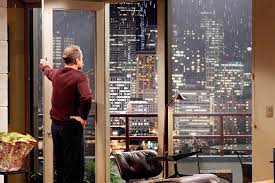

In [46]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

%matplotlib inline

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Reset plotting styles (important for PyCharm Jupyter)
plt.style.use("default")
mpl.rcdefaults()
sns.reset_defaults()

# Make text visible
mpl.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "font.size": 12
})

In [32]:
# Import Pandas

# Load the file
df = pd.read_csv("data/eda.csv")

# Take a look inside
df.head()

,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.000,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,...,7,1180.000,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000
1,2014-12-09,538000.000,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,...,7,2170.000,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000
2,2015-02-25,180000.000,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,...,6,770.000,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000
3,2014-12-09,604000.000,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,...,7,1050.000,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000
4,2015-02-18,510000.000,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,...,8,1680.000,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000


In [31]:
# Check the size
df.shape

(21597, 21)

The dataset contains approximately 21,597 house sales and around 23 variables describing each property.

In [33]:
# See every Column
df.columns

Index(['date', 'price', 'id', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

In [72]:
df.isnull().sum().sort_values(ascending=False)

yr_renovated     3848
waterfront       2391
sqft_basement     452
view               63
date                0
house_age           0
sale_month          0
sqft_lot15          0
sqft_living15       0
long                0
lat                 0
zipcode             0
yr_built            0
sqft_above          0
price               0
grade               0
condition           0
floors              0
sqft_lot            0
sqft_living         0
bathrooms           0
bedrooms            0
id                  0
renovated           0
dtype: int64

Missing values are limited to a few columns and do not appear to affect most of the analysis.

In [37]:
# Clean the column names (remove invisible spaces)
df.columns = df.columns.str.strip()

# Convert the date
df["date"] = pd.to_datetime(df["date"])

# Make helper column - Sale month
df["sale_month"] = df["date"].dt.month

# Make helper column - House Age
df["house_age"] = df["date"].dt.year - df["yr_built"]

Q1. How expensive are houses?

In [38]:
df["price"].describe()

count     21597.000
mean     540296.574
std      367368.140
min       78000.000
25%      322000.000
50%      450000.000
75%      645000.000
max     7700000.000
Name: price, dtype: float64

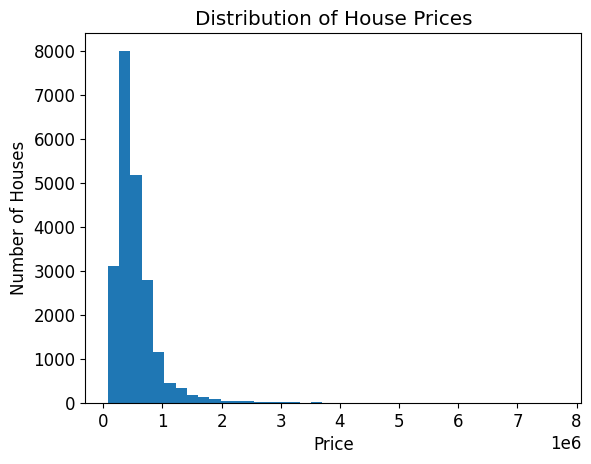

In [58]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=40)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

Most houses sell below the highest prices, while a small number of luxury homes create a long tail in the distribution.


Q2. Do bigger houses cost more?

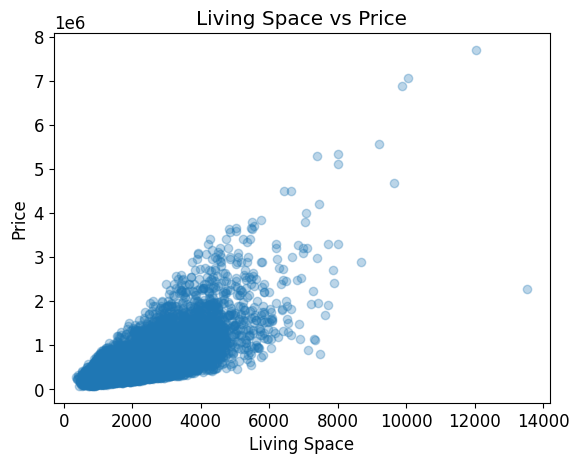

In [59]:
plt.scatter(df["sqft_living"], df["price"], alpha=0.3)
plt.xlabel("Living Space")
plt.ylabel("Price")
plt.title("Living Space vs Price")
plt.show()

Houses with more living space generally sell for higher prices.

Q3. Which neighborhoods are expensive?

In [60]:
zip_prices = (
    df.groupby("zipcode")["price"]
      .mean()
      .sort_values(ascending=False)
)

In [61]:
# Show top 10
zip_prices.head(10)

zipcode
98039   2161300.000
98004   1356523.991
98040   1194873.638
98112   1096239.007
98102    899607.673
98109    880077.752
98105    863228.943
98006    859938.554
98119    849714.810
98005    810289.696
Name: price, dtype: float64

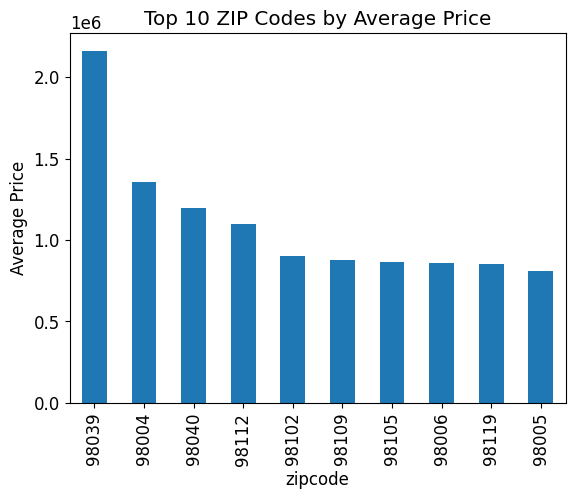

In [62]:
zip_prices.head(10).plot(kind="bar")
plt.title("Top 10 ZIP Codes by Average Price")
plt.ylabel("Average Price")
plt.show()

Q4. Are renovated houses worth more?

In [63]:
# Create True/ False column
df["renovated"] = df["yr_renovated"] > 0

# Compare them
df.groupby("renovated")["price"].mean()

renovated
False   532140.320
True    768901.892
Name: price, dtype: float64

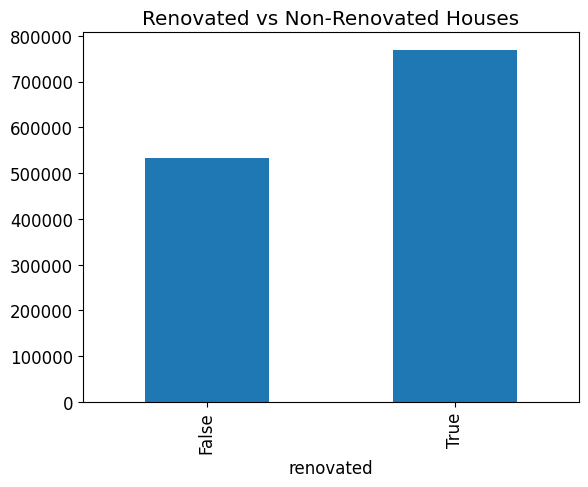

In [64]:
df.groupby("renovated")["price"].mean().plot(kind="bar")
plt.title("Renovated vs Non-Renovated Houses")
plt.show()

Q5. What's the best time to sell?

In [68]:
# Average price by month

monthly_prices = df.groupby("sale_month")["price"].mean()

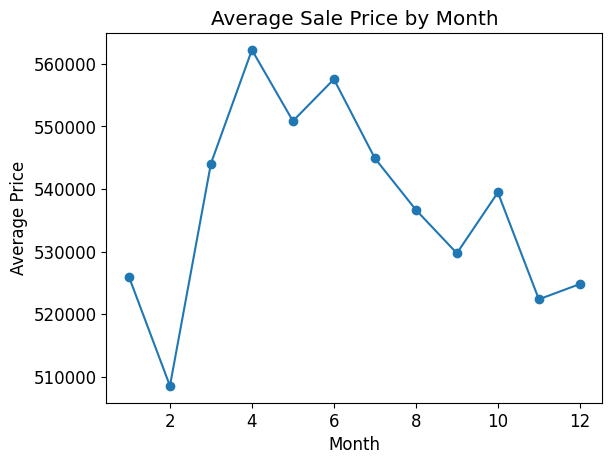

In [69]:
monthly_prices = df.groupby("sale_month")["price"].mean()

monthly_prices.plot(marker="o")
plt.title("Average Sale Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.show()

April is the highest sale month, February the lowest

In [70]:
df["price"].describe()

count     21597.000
mean     540296.574
std      367368.140
min       78000.000
25%      322000.000
50%      450000.000
75%      645000.000
max     7700000.000
Name: price, dtype: float64

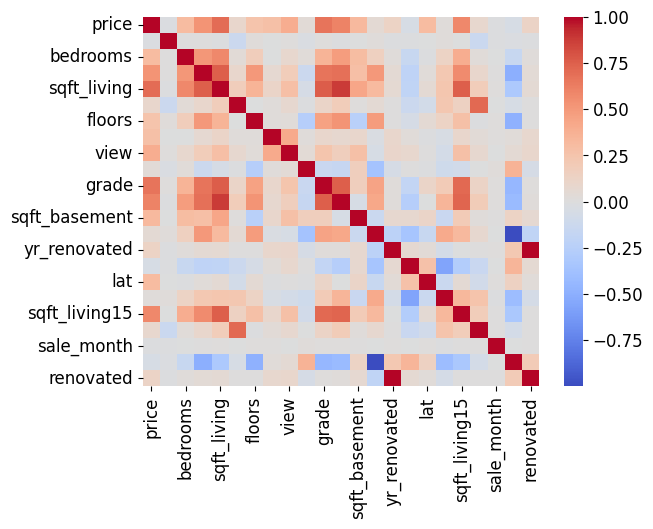

In [74]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

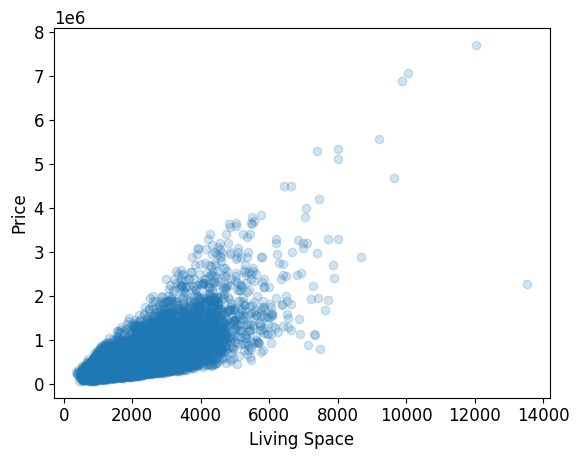

In [77]:
plt.scatter(df["sqft_living"], df["price"], alpha=0.2)
plt.xlabel("Living Space")
plt.ylabel("Price")
plt.show()